# Supplementary Figure S4: analog characterisation (related to Figure 5)

Four panels, rendered as a single 6.5 x 8.5 in figure for Cell submission.

- **Panel A** - MSAs for the six inactive-prototype families. Row labels follow
  the Omega-mode-number convention (e.g. Ω-AT-5, Ω-AP-4). Template fully coloured
  by chemistry; analog residues coloured only where they match the template.
  Template names and lead analogs bolded.
- **Panel B** - *Transposed* MIC heatmap: strains on the y-axis (readable
  horizontal labels), all 65 peptides on the x-axis in family-ordered blocks.
  HC50 and CC50 as a narrow strip directly below the MIC heatmap. Colour scale
  is recentred at 8 μM with a stretched low-MIC segment so sub-micromolar cells
  render as distinctly darker burgundy than 1 μM cells.
- **Panel C** - Pooled conditioning-strategy comparison across all 59 analogs.
  Dots coloured by prototype family; lead analogs with a black marker edge.
- **Panel D** - α-helix fraction in SDS micelles by prototype family (BeStSel
  fits of CD spectra). Horizontal strip plot in the Figure 5 F/G style: 6
  families with prototype diamond + analog dots, plus a de novo reference row
  on top. Leads have black-outlined markers and Ω-family-letter-number callouts.
  Kruskal-Wallis test with ε² effect size in the corner.

In [1]:
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

PROJECT = Path("/home/pszymczak/code/omegamp-dashboard/data")
OUT = Path("/home/pszymczak/code/omegamp-dashboard/figures")
OUT.mkdir(parents=True, exist_ok=True)

matplotlib.font_manager._load_fontmanager(try_read_cache=False)
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "axes.edgecolor": "#333333",
    "xtick.color": "#333333", "ytick.color": "#333333",
    "axes.labelcolor": "#222222",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "figure.dpi": 300, "savefig.dpi": 600,
    "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.major.pad": 2, "ytick.major.pad": 2,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

## Load data and derive family assignments


In [2]:
ref = pd.read_csv(PROJECT / "omegamp_reference_table.csv")
mic = pd.read_csv(PROJECT / "mic.csv")

hc50 = pd.read_csv(PROJECT / "hc50.csv")
cc50 = pd.read_csv(PROJECT / "cc50.csv")
_dc = lambda v: float(str(v).lstrip('>')) if pd.notna(v) else float('nan')
for _c in mic.columns[1:]:
    mic[_c] = mic[_c].apply(_dc)
hc50['HC50'] = hc50['HC50'].apply(_dc)
cc50['CC50'] = cc50['CC50'].apply(_dc)

bestsel = pd.read_csv(PROJECT / "bestsel.csv")
# At-MIC NPN/DiSC: each peptide assayed at its own MIC (Panel E/F)
npn_at_mic = pd.read_csv(PROJECT / "npn.csv")
disc_at_mic = pd.read_csv(PROJECT / "disc.csv")

# Prototype-column bookkeeping: two prototypes use DBAASPS IDs in the reference
PROTO_MAP = {"DBAASPS_20015": "As-CATH4-6L", "DBAASPS_20955": "OP-145-TII4"}

def resolve_family(row):
    if row["category"] == "prototype":
        return row["short_name"]
    p = str(row.get("prototype", ""))
    return PROTO_MAP.get(p, p) if p != "nan" else ""

ref["family"] = ref.apply(resolve_family, axis=1)
antimicrobial = ref[(ref["category"] == "analog")
                    & (ref["objective"] == "antimicrobial")].copy()
protos = ref[ref["category"] == "prototype"].set_index("family")

print(f"Prototypes:   {len(protos)}")
print(f"Antimicrobial analogs: {len(antimicrobial)}")



Prototypes:   11
Antimicrobial analogs: 59


## Colours, leads, family ordering

`FC` matches Figure 5's family palette. `COND_COLOUR` is a separate palette for
AP/AT/AU. `LEADS_SET` contains the four analogs bolded throughout the figure.


In [3]:
INACTIVE_ORDER = ["Mammutin-1", "GQ20", "As-CATH4-6L", "BoCo1",
                  "DeNo1047", "OP-145-TII4"]

# Family palette (matched to main Figure 5)
FC = {"Mammutin-1": "#D55E00", "GQ20": "#E69F00", "BoCo1": "#009E73",
      "DeNo1047": "#56B4E9", "As-CATH4-6L": "#0072B2",
      "OP-145-TII4": "#CC79A7"}

# Conditioning palette (distinct from family colours)
COND_COLOUR = {"AP": "#6a3d9a", "AT": "#1f78b4", "AU": "#33a02c"}

# Leads highlighted in Figure 5 and Table 1
LEADS_SET = {
    "Ω-AT-BoCo1-5", "Ω-AT-BoCo1-9",
    "Ω-AU-GQ20-4", "Ω-AP-Mammutin-1-4",
}
LEADS_SHORT = {
    "Ω-AT-BoCo1-5": "Ω-B-5", "Ω-AT-BoCo1-9": "Ω-B-9",
    "Ω-AU-GQ20-4": "Ω-G-4", "Ω-AP-Mammutin-1-4": "Ω-M-4",
}

# ClustalX-style AA palette (matched to Figure S4)
AA_COLORS = {
    "A": "#87A7E0", "I": "#87A7E0", "L": "#87A7E0", "M": "#87A7E0",
    "F": "#87A7E0", "W": "#87A7E0", "V": "#87A7E0", "C": "#E787E0",
    "K": "#E87A7A", "R": "#E87A7A",
    "D": "#C256B0", "E": "#C256B0",
    "N": "#85C285", "Q": "#85C285", "S": "#85C285", "T": "#85C285",
    "G": "#F0A555", "P": "#D4C540",
    "H": "#5EC6C6", "Y": "#5EC6C6",
}

## Per-family peptide table

Returns `[prototype_row, analog_1, ..., analog_N]` ordered by conditioning then
by trailing numeric index.


In [4]:
def family_rows(family):
    """Return [prototype_row, analog_row_1, ..., analog_row_N] for a family,
    sorted by numeric index (1, 2, 3, ...)."""
    rows = []
    if family in protos.index:
        p = protos.loc[family].copy()
        p["family"] = family
        rows.append(p)
    sub = antimicrobial[antimicrobial["family"] == family].copy()
    sub["idx"] = sub["short_name"].str.extract(r"-(\d+)$").astype(int)
    sub = sub.sort_values("idx")
    for _, r in sub.iterrows():
        rows.append(r)
    return rows

## Panel A: alignment drawing

Row labels use the Ω-mode-number convention (`Ω-AT-5`). `label_space` is set
dynamically from the longest row label so long family names like `As-CATH4-6L`
(11 characters) do not crop.


In [5]:
def draw_alignment(ax, family, fontsize=6, row_stride=1.7):
    """Draw an MSA grid for a prototype family.

    row_stride: spacing between rows in data units. With set_aspect("equal")
    and Rectangle((j, y), 1, 1), row_stride > 1 inserts whitespace between
    rows so 6 pt letters do not overlap vertically. Default 1.7 gives a
    comfortable visual gap.
    """
    rows = family_rows(family)
    labels = [family]
    seqs = [rows[0]["sequence"]]
    bolds = [True]
    for r in rows[1:]:
        parts = r["short_name"].split("-")
        cond = r["conditioning"]
        idx = parts[-1]
        labels.append(f"Ω-{cond}-{idx}")
        seqs.append(r["sequence"])
        bolds.append(r["short_name"] in LEADS_SET)

    template = seqs[0]
    max_len = max(len(s) for s in seqs)
    n = len(seqs)
    label_space = max(len(labels[0]), max(len(l) for l in labels[1:])) + 5.0

    for i, (lab, seq, b) in enumerate(zip(labels, seqs, bolds)):
        y = (n - 1 - i) * row_stride  # spaced rows
        is_template = (i == 0)
        weight = "bold" if b else "normal"
        ax.text(-0.3, y + 0.5, lab, ha="right", va="center",
                fontsize=fontsize, family="monospace", fontweight=weight)
        for j, aa in enumerate(seq):
            if is_template:
                color = AA_COLORS.get(aa, "white")
            else:
                color = AA_COLORS.get(aa, "white") if (j < len(template) and aa == template[j]) else "white"
            ax.add_patch(Rectangle((j, y), 1, 1, facecolor=color,
                                   edgecolor="none", linewidth=0))
            ax.text(j + 0.5, y + 0.5, aa, ha="center", va="center",
                    fontsize=fontsize, family="monospace", color="black",
                    fontweight=weight)

    # Family title above topmost row
    y_top = (n - 1) * row_stride
    ax.text(max_len / 2, y_top + 1.6, family, ha="center", va="bottom",
            fontsize=fontsize + 1.5, fontweight="bold", color=FC[family])
    ax.set_xlim(-label_space, max_len + 0.3)
    ax.set_ylim(-0.3, y_top + 1.9)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


## Panel B: transposed MIC heatmap + HC50/CC50 strip

Strains on the y-axis (readable horizontal labels). All 65 peptides on the x-axis.
Cells with MIC > 64 μM are masked light gray (tested-but-inactive - rendered as
`NaN` in `mic.csv`). The MIC colour scale has a stretched low-MIC segment so
sub-μM cells render as a distinct dark burgundy, and `TwoSlopeNorm(vcenter=8)`
puts the red-to-blue transition at the standard AMP "active" threshold.

Deliberate departure from Figure 5E: this heatmap is transposed, so strain labels
are horizontal and the peptide axis is packed densely across the x. Figure 5E
labels every cell with a numeric MIC; here we rely on colour alone.


In [6]:
# =========================================================================
STRAIN_LABELS = {
    "A. baumannii ATCC 19606 (-)": "$\\it{A. baumannii}$ ATCC 19606",
    "A. baumannii ATCC BAA-1605 (-) - CGTPACCIMRA":
        "$\\it{A. baumannii}$ ATCC BAA-1605",
    "E. cloacae ATCC 13047 (-)": "$\\it{E. cloacae}$ ATCC 13047",
    "E. coli ATCC 11775 (-)": "$\\it{E. coli}$ ATCC 11775",
    "E. coli AIC221 (-)": "$\\it{E. coli}$ AIC221",
    "E. coli AIC222 - CRE (-)": "$\\it{E. coli}$ AIC222",
    "E. coli ATCC BAA-3170 (-) - CRE": "$\\it{E. coli}$ ATCC BAA-3170",
    "K. pneumoniae ATCC 13883 (-)": "$\\it{K. pneumoniae}$ ATCC 13883",
    "K. pneumoniae ATCC BAA-2342 (-) - EIRK":
        "$\\it{K. pneumoniae}$ ATCC BAA-2342",
    "P. aeruginosa PAO1 (-)": "$\\it{P. aeruginosa}$ PAO1",
    "P. aeruginosa PA14 (-)": "$\\it{P. aeruginosa}$ PA14",
    "P. aeruginosa ATCC BAA-3197 (-) - FBCRP":
        "$\\it{P. aeruginosa}$ ATCC BAA-3197",
    "S. enterica ATCC 9150 (-)": "$\\it{S. enterica}$ ATCC 9150",
    "S. enterica Typhimurtium ATCC 700720": "$\\it{S. enterica}$ Typhimurium",
    "B. subtilis ATCC 23857 (+)": "$\\it{B. subtilis}$ ATCC 23857",
    "S. aureus ATCC 12600 (+)": "$\\it{S. aureus}$ ATCC 12600",
    "S. aureus ATCC BAA-1556 - MRSA (+)":
        "$\\it{S. aureus}$ ATCC BAA-1556",
    "E. faecalis ATCC 700802 - VRE (+)":
        "$\\it{E. faecalis}$ ATCC 700802",
    "E. faecium ATCC 700221 - VRE (+)":
        "$\\it{E. faecium}$ ATCC 700221",
    "E. coli K-12 BW25113 (-)": "$\\it{E. coli}$ K-12 BW25113",
}

mic_strains = list(mic.columns[1:])
# Same strain ordering as Figure 5: cluster the E. coli strains together
ecoli_strains = [s for s in mic_strains if "E. coli" in s or "coli" in s.lower()]
strain_order = []
for s in mic_strains:
    if s in ecoli_strains:
        continue
    strain_order.append(s)
    if "cloacae" in s.lower():
        strain_order.extend(ecoli_strains)
if not any("coli" in s.lower() for s in strain_order):
    strain_order.extend(ecoli_strains)

STRAIN_MDR = {s: any(t in s for t in ["CRAB", "CRE", "ESBL", "EIRK",
                                      "FBCR", "FQR", "MRSA", "VRE", "CGTPA"])
              for s in mic_strains}
STRAIN_GRAM = {s: ("+" if "(+)" in s else "-") for s in mic_strains}

# Colour maps
MIC_CMAP = LinearSegmentedColormap.from_list(
    "mic_rb", [(0.0,  "#67000d"),
              (0.08, "#b2182b"),
              (0.25, "#ef8a62"),
              (0.5,  "#f7f7f7"),
              (0.75, "#67a9cf"),
              (1.0,  "#2166ac")])
MIC_NORM = TwoSlopeNorm(vmin=0, vcenter=32, vmax=64)

TOX_CMAP = LinearSegmentedColormap.from_list(
    "tox_gr", [(0.0, "#b2182b"), (0.2, "#ef8a62"), (0.4, "#fddbc7"),
              (0.5, "#f7f7f7"), (0.6, "#a6d96a"), (0.8, "#1a9641"),
              (1.0, "#006837")])
TOX_NORM = TwoSlopeNorm(vmin=0.1, vcenter=1, vmax=128)


In [7]:
_GAP = "\x00"  # sentinel for family-separator columns

def draw_full_heatmap(ax_mic, ax_tox, cax_mic, cax_tox):
    """Transposed heatmap: strains on y-axis, peptides on x-axis.

    All cells — including untested / inactive (MIC ≥ 64) — are rendered
    purely by the MIC colormap after clipping to [0, 64]. No special
    grey overlays are applied; the top of the colour scale (dark blue)
    represents both 'tested-but-inactive' and 'not tested' cells.
    """
    mic_dict = {r["short_name"]: r for _, r in mic.iterrows()}
    hc50_dict = dict(zip(hc50["short_name"],
                         pd.to_numeric(hc50["HC50"].astype(str).str.replace(r'^', '', regex=False), errors="coerce").clip(0.1, 128)))
    cc50_dict = dict(zip(cc50["short_name"],
                         pd.to_numeric(cc50["CC50"], errors="coerce").clip(0.1, 128)))

    # Peptides along x-axis, with one white-gap column inserted between families
    pep_names, pep_labels, pep_colors, pep_bold = [], [], [], []
    for fi, fam in enumerate(INACTIVE_ORDER):
        if fi > 0:                       # family separator
            pep_names.append(_GAP)
            pep_labels.append("")
            pep_colors.append("none")
            pep_bold.append(False)
        rows = family_rows(fam)
        for r in rows:
            nm = r["short_name"]
            pep_names.append(nm)
            if r.get("category") == "prototype":
                pep_labels.append(fam)
            else:
                idx = nm.split("-")[-1]
                pep_labels.append(f"Ω-{r['conditioning']}-{idx}")
            pep_colors.append(FC[fam])
            pep_bold.append(r.get("category") == "prototype" or nm in LEADS_SET)

    n_pep = len(pep_names)
    n_strains = len(strain_order)
    gap_cols = [j for j, nm in enumerate(pep_names) if nm == _GAP]

    # MIC matrix: default 128 (= missing = >64). Clip to [0,64] before imshow
    # so the colormap handles every cell uniformly.
    hm = np.full((n_strains, n_pep), 128.0)
    for j, nm in enumerate(pep_names):
        if nm == _GAP:
            continue
        if nm in mic_dict:
            for i, s in enumerate(strain_order):
                v = mic_dict[nm].get(s, np.nan)
                if pd.notna(v):
                    hm[i, j] = float(v)

    im_mic = ax_mic.imshow(hm.clip(0, 64), aspect="auto", cmap=MIC_CMAP,
                           norm=MIC_NORM, interpolation="nearest")

    # White separator columns (one tall rectangle per gap)
    for j in gap_cols:
        ax_mic.add_patch(Rectangle((j - 0.5, -0.5), 1, n_strains,
                                   facecolor="white", edgecolor="none", zorder=3))

    # Strain labels on the y-axis
    ax_mic.set_yticks(range(n_strains))
    ax_mic.tick_params(axis="y", which="major", pad=2, length=0)
    ylabs = ax_mic.set_yticklabels([STRAIN_LABELS.get(s, s) for s in strain_order],
                                   fontsize=6)
    for yi, s in enumerate(strain_order):
        ylabs[yi].set_color("#DC2626" if STRAIN_GRAM[s] == "+" else "#2563EB")
        if STRAIN_MDR[s]:
            ylabs[yi].set_fontweight("bold")
    ax_mic.set_xticks([])
    ax_mic.set_xlim(-0.5, n_pep - 0.5)

    # --- HC50 / CC50 strip ---
    tox_mat = np.full((2, n_pep), np.nan)
    for j, nm in enumerate(pep_names):
        if nm == _GAP:
            continue
        tox_mat[0, j] = hc50_dict.get(nm, np.nan)
        tox_mat[1, j] = cc50_dict.get(nm, np.nan)

    tox_ma = np.ma.array(tox_mat, mask=np.isnan(tox_mat))
    tox_cmap_masked = TOX_CMAP.copy()
    tox_cmap_masked.set_bad("#dddddd")
    im_tox = ax_tox.imshow(tox_ma, aspect="auto", cmap=tox_cmap_masked,
                           norm=TOX_NORM, interpolation="nearest")

    # White separators in tox strip
    for j in gap_cols:
        ax_tox.add_patch(Rectangle((j - 0.5, -0.5), 1, 2,
                                   facecolor="white", edgecolor="none", zorder=3))

    ax_tox.set_yticks([0, 1])
    ax_tox.set_yticklabels(["HC$_{50}$", "CC$_{50}$"], fontsize=6,
                           fontweight="bold")
    ax_tox.tick_params(axis="y", which="major", pad=2, length=0)

    # Peptide labels along x-axis of tox strip (90° rotation, extra pad for readability)
    ax_tox.set_xticks(range(n_pep))
    ax_tox.tick_params(axis="x", which="major", pad=5, length=0)
    xlabs = ax_tox.set_xticklabels(pep_labels, rotation=90, ha="right",
                                   fontsize=6, family="monospace")
    for xi, (c, b) in enumerate(zip(pep_colors, pep_bold)):
        xlabs[xi].set_color(c)
        if b:
            xlabs[xi].set_fontweight("bold")
    ax_tox.set_xlim(-0.5, n_pep - 0.5)

    # --- Colourbars ---
    cb_mic = plt.colorbar(im_mic, cax=cax_mic)
    cb_mic.set_label("")  # avoid right-side label overlap
    cb_mic.ax.set_title("MIC\n(μM)", fontsize=6, pad=4, loc="center")
    cb_mic.set_ticks([0, 1, 8, 16, 32, 64])
    cb_mic.ax.minorticks_off()
    cb_mic.ax.tick_params(labelsize=6)
    cb_mic.outline.set_visible(False)

    cb_tox = plt.colorbar(ScalarMappable(norm=TOX_NORM, cmap=TOX_CMAP),
                          cax=cax_tox)
    cb_tox.set_label("")
    cb_tox.ax.set_title("HC$_{50}$/CC$_{50}$\n(μM)", fontsize=6, pad=4, loc="center")
    cb_tox.set_ticks([0.1, 1, 10, 100])
    cb_tox.set_ticklabels(["0.1", "1", "10", "≥128"])
    cb_tox.ax.minorticks_off()
    cb_tox.ax.tick_params(labelsize=6)
    cb_tox.outline.set_visible(False)


## Panel D: α-helix fraction in SDS by prototype family

Horizontal strip plot matching Figure 5 F/G style. Each row is a prototype
family with its prototype as a coloured diamond and analogs as smaller dots;
leads have black-outlined markers and labelled callouts using the
Ω-family-letter-number convention. A de novo reference row sits at the top.
Kruskal-Wallis test with ε² rank-based effect size annotates the bottom-right.

BeStSel fits of CD spectra: `fH_SDS_H2O` reports the fraction of α-helical
content estimated from CD data recorded in 30 mM SDS micelles, a standard
membrane-mimetic for AMPs.

In [8]:
from scipy.stats import kruskal

LEAD_HELIX_OFFSETS = {
    "Ω-AT-BoCo1-5":      (10,  10),
    "Ω-AT-BoCo1-9":      (10, -10),
    "Ω-AU-GQ20-4":       (-10, 10),
    "Ω-AP-Mammutin-1-4": (10,  10),
}

def draw_helix_panel(ax):
    """Horizontal strip of fH_SDS_H2O by family, with de novo reference on top.

    Order matches Figure 5 F/G: families bottom-to-top, de novo above all six
    family rows. Leads are highlighted with black-outlined markers and
    Ω-family-letter-number callouts. KW + ε² in lower-right corner.
    """
    bs = bestsel.merge(
        ref[["short_name", "category", "family", "objective"]],
        on="short_name", how="left",
    )
    ana = bs[(bs["category"] == "analog")
             & (bs["objective"] == "antimicrobial")].copy()
    dn = bs[bs["category"] == "de_novo"]

    fam_order = INACTIVE_ORDER[::-1]  # bottom-to-top

    # De novo reference row at y = len(fam_order) = 6 (top)
    dn_y = len(fam_order)
    dn_jit = np.random.RandomState(17).normal(0, 0.10, len(dn))
    ax.scatter(dn["fH_SDS_H2O"].values, dn_y + dn_jit,
               c="#888888", s=7, alpha=0.5, edgecolors="none", zorder=3)

    # Median across all de novo as a soft reference line
    dn_med = dn["fH_SDS_H2O"].median()
    ax.axvline(dn_med, color="#ccc", ls=":", lw=0.5, zorder=1)

    groups = []
    for i, fam in enumerate(fam_order):
        fd = ana[ana["family"] == fam]
        color = FC[fam]
        if len(fd) == 0:
            continue

        # Prototype diamond
        if fam in protos.index:
            pname = protos.loc[fam, "short_name"]
            p_helix = bestsel.loc[bestsel["short_name"] == pname, "fH_SDS_H2O"]
            if len(p_helix) > 0:
                ax.scatter(p_helix.values[0], i, marker="D", c=color,
                           edgecolors="none", s=18, zorder=5)

        groups.append(fd["fH_SDS_H2O"].dropna().values)
        jit = np.random.RandomState(100 + i).normal(0, 0.10, len(fd))
        for j, (_, row) in enumerate(fd.iterrows()):
            is_lead = row["short_name"] in LEADS_SET
            if is_lead:
                ax.scatter(row["fH_SDS_H2O"], i + jit[j], c=color, s=14,
                           edgecolors="black", linewidth=0.5, zorder=5)
                idx = row["short_name"].split("-")[-1]
                fam_letter = fam[0]
                short_lab = f"Ω-{fam_letter}-{idx}"
                off = LEAD_HELIX_OFFSETS.get(row["short_name"], (10, 10))
                ha = "right" if off[0] < 0 else "left"
                ax.annotate(short_lab, (row["fH_SDS_H2O"], i + jit[j]),
                            xytext=off, textcoords="offset points",
                            fontsize=6, ha=ha, va="center", color="black",
                            arrowprops=dict(arrowstyle="-", color="#555", lw=0.5),
                            zorder=10)
            else:
                ax.scatter(row["fH_SDS_H2O"], i + jit[j], c=color, s=12,
                           marker="o", edgecolors="none", alpha=0.7, zorder=3)

    # KW + eta^2 (consistent with Figure 5 D-G)
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        H, p = kruskal(*groups)
        n_total = sum(len(g) for g in groups)
        k = len(groups)
        eta2 = H / (n_total - 1)
        ax.set_title(f"KW $p$ = {p:.1e}, $\\eta^2$ = {eta2:.2f}",
                     loc="right", fontsize=6, color="#555",
                     fontweight="bold", pad=2)

    ax.set_yticks(list(range(len(fam_order))) + [len(fam_order)])
    ylabs = ax.set_yticklabels(fam_order + ["$\\it{De\\;novo}$"], fontsize=6)
    for y_obj, f in zip(ylabs[:-1], fam_order):
        y_obj.set_color(FC[f])
    ylabs[-1].set_color("#666")
    ax.set_xlabel("α-helix fraction in SDS (%)", fontsize=6)
    ax.set_xlim(-2, 105)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


## Panels E + F: NPN and DiSC₃(5) at MIC

Each peptide assayed at its own MIC against an indicator strain (conventional
at-MIC design). Comparison to Figure 5F/G which uses family-anchored fixed
concentrations.

In [9]:
LEAD_OFFSETS_MEM = {
    "Ω-AT-BoCo1-5":      {"NPN": (10, -14), "DiSC": (10, -12)},
    "Ω-AT-BoCo1-9":      {"NPN": (10,  14), "DiSC": (10,  12)},
    "Ω-AU-GQ20-4":       {"NPN": (10, -12), "DiSC": (10, -12)},
    "Ω-AP-Mammutin-1-4": {"NPN": (10,  12), "DiSC": (10,  12)},
}

def draw_membrane_panels(ax_e, ax_f):
    """NPN and DiSC₃(5) strip plots (at-MIC assay), panels E and F."""
    _ana = antimicrobial.merge(
        npn_at_mic.rename(columns={"MaxRel": "NPN"})[["short_name", "NPN"]],
        on="short_name", how="left",
    ).merge(
        disc_at_mic.rename(columns={"MaxRel": "DiSC"})[["short_name", "DiSC"]],
        on="short_name", how="left",
    )
    mech = _ana.dropna(subset=["NPN", "DiSC"])

    _dn = ref[ref["category"] == "de_novo"].merge(
        npn_at_mic.rename(columns={"MaxRel": "NPN"})[["short_name", "NPN"]],
        on="short_name", how="left",
    ).merge(
        disc_at_mic.rename(columns={"MaxRel": "DiSC"})[["short_name", "DiSC"]],
        on="short_name", how="left",
    )
    dn_mech = _dn.dropna(subset=["NPN", "DiSC"])

    npn_med = _ana["NPN"].dropna().median()
    disc_med = _ana["DiSC"].dropna().median()
    fam_order = INACTIVE_ORDER[::-1]

    for ax, metric, med_val, xlabel_text, letter in [
        (ax_e, "NPN",  npn_med,
         "Outer membrane permeabilization\nNPN MaxRel (%) at MIC", "E"),
        (ax_f, "DiSC", disc_med,
         "Cytoplasmic membrane depolarization\nDiSC$_3$(5) MaxRel (%) at MIC", "F"),
    ]:
        dn_y = len(fam_order)
        dn_jit = np.random.RandomState(17 + (0 if metric == "NPN" else 1)).normal(
            0, 0.10, len(dn_mech))
        ax.scatter(dn_mech[metric].values, dn_y + dn_jit,
                   c="#888888", s=7, alpha=0.5, edgecolors="none", zorder=3)

        for i, fam in enumerate(fam_order):
            fd = mech[mech["family"] == fam]
            color = FC[fam]
            if len(fd) == 0:
                continue
            if fam in protos.index:
                pname = protos.loc[fam, "short_name"]
                pr = _ana[_ana["short_name"] == pname].dropna(subset=[metric])
                if len(pr) > 0:
                    ax.scatter(pr[metric].values, [i], marker="D", c=color,
                               edgecolors="none", s=15, zorder=5)
            jit = np.random.RandomState(
                i + 300 + (0 if metric == "NPN" else 100)).normal(0, 0.10, len(fd))
            for j, (_, row) in enumerate(fd.iterrows()):
                is_lead = row["short_name"] in LEADS_SET
                if is_lead:
                    ax.scatter(row[metric], i + jit[j], c=color, s=14,
                               edgecolors="black", linewidth=0.5, zorder=5)
                    off = LEAD_OFFSETS_MEM.get(row["short_name"], {}).get(metric, (10, 10))
                    ha = "right" if off[0] < 0 else "left"
                    ax.annotate(LEADS_SHORT.get(row["short_name"], row["short_name"]),
                                (row[metric], i + jit[j]),
                                xytext=off, textcoords="offset points",
                                fontsize=6, ha=ha, va="center", color="black",
                                arrowprops=dict(arrowstyle="-", color="#555", lw=0.5),
                                zorder=10)
                else:
                    ax.scatter(row[metric], i + jit[j], c=color, s=12,
                               marker="o", edgecolors="none", alpha=0.7, zorder=3)

        ax.axvline(med_val, color="#ccc", ls=":", lw=0.5, zorder=1)
        ax.set_yticks(list(range(len(fam_order))) + [dn_y])
        yl = ax.set_yticklabels(fam_order + ["$\\it{De\\;novo}$"], fontsize=6)
        for y_obj, f in zip(yl[:-1], fam_order):
            y_obj.set_color(FC[f])
        yl[-1].set_color("#666")
        ax.set_xlabel(xlabel_text, fontsize=6)
        groups = [mech[mech["family"] == f][metric].dropna().values
                  for f in INACTIVE_ORDER]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) >= 2:
            H, p = kruskal(*groups)
            n_total = sum(len(g) for g in groups)
            k = len(groups)
            eta2 = H / (n_total - 1)
            ax.set_title(f"KW $p$ = {p:.1e}, $\\eta^2$ = {eta2:.2f}",
                         loc="right", fontsize=6, color="#555",
                         fontweight="bold", pad=2)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)

## Panel C: pooled conditioning comparison

All 59 analogs on a single panel split by conditioning strategy (Ω-AP, Ω-AT,
Ω-AU). y-axis: number of strains with MIC ≤ 2 μM. Dots are coloured by prototype
family so the family-conditioning coupling (Mammutin-1 and OP-145-TII4 are
AP-only; As-CATH4-6L and BoCo1 are mostly AT; GQ20 is split AT/AU) is visible
rather than hidden.

In [10]:
from scipy.stats import kruskal

LEAD_COND_OFFSETS = {
    "Ω-AT-BoCo1-5":      (16, -8),
    "Ω-AT-BoCo1-9":      (-16, 8),
    "Ω-AU-GQ20-4":       (10, -12),
    "Ω-AP-Mammutin-1-4": (14, 10),
}

def draw_cond_panel(ax):
    mic_vals = mic[mic_strains].astype(float)
    n_le2_dict = dict(zip(mic["short_name"], (mic_vals <= 2).sum(axis=1)))

    sub = antimicrobial.copy()
    sub["n_le2"] = sub["short_name"].map(n_le2_dict).fillna(0)

    cond_order = ["AP", "AT", "AU"]
    for xi, cond in enumerate(cond_order):
        grp = sub[sub["conditioning"] == cond]
        if len(grp) == 0:
            continue
        ax.boxplot([grp["n_le2"].values], positions=[xi], widths=0.55,
                   patch_artist=True, vert=True, zorder=2,
                   showfliers=False,
                   boxprops=dict(facecolor="#cccccc", alpha=0.40,
                                 edgecolor="#777777", linewidth=0.7),
                   whiskerprops=dict(color="#777777", linewidth=0.7),
                   medianprops=dict(color="#333333", linewidth=1.2),
                   capprops=dict(color="#777777", linewidth=0.7))
        jit = np.random.RandomState(hash(cond) % 1000).normal(0, 0.10, len(grp))
        for j, (_, r) in enumerate(grp.iterrows()):
            is_lead = r["short_name"] in LEADS_SET
            if is_lead:
                ax.scatter(xi + jit[j], r["n_le2"], c=FC[r["family"]],
                           s=14, edgecolors="black", linewidth=0.5, zorder=5)
            else:
                ax.scatter(xi + jit[j], r["n_le2"], c=FC[r["family"]],
                           s=12, marker="o", edgecolors="none", alpha=0.7, zorder=3)
            if is_lead:
                fam_letter = r["family"][0]
                idx_str = r["short_name"].split("-")[-1]
                short_lab = f"Ω-{fam_letter}-{idx_str}"
                off = LEAD_COND_OFFSETS.get(r["short_name"], (10, 8))
                ha = "right" if off[0] < 0 else "left"
                ax.annotate(short_lab, (xi + jit[j], r["n_le2"]),
                            xytext=off, textcoords="offset points",
                            fontsize=6, ha=ha, va="center", color="black",
                            arrowprops=dict(arrowstyle="-", color="#555", lw=0.5),
                            zorder=10)
        ax.text(xi, 16.5, f"n={len(grp)}", ha="center", va="top",
                fontsize=6, color="#444", fontweight="bold")

    cond_groups = [sub[sub["conditioning"] == c]["n_le2"].values
                   for c in cond_order if len(sub[sub["conditioning"] == c]) > 0]
    if len(cond_groups) >= 2:
        H, p = kruskal(*cond_groups)
        n_total = sum(len(g) for g in cond_groups)
        k = len(cond_groups)
        eta2 = H / (n_total - 1)
        ax.set_title(f"KW $p$ = {p:.2g}, $\\eta^2$ = {eta2:.2f}",
                     loc="right", fontsize=6, color="#555",
                     fontweight="bold", pad=2)

    ax.set_xticks(range(len(cond_order)))
    ax.set_xticklabels([f"$\\Omega$-{c}" for c in cond_order],
                       fontsize=6, fontweight="bold")
    for xl, c in zip(ax.get_xticklabels(), cond_order):
        xl.set_color(COND_COLOUR[c])
    ax.set_xlim(-0.5, len(cond_order) - 0.5)
    ax.set_ylim(-1, 17)
    ax.set_ylabel("Strains with MIC $\\leq$ 2 μM", fontsize=6)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

## Assemble the full figure

Layout for the 6.5 x 8.0 inch figure:

- Panel A on top - 3 MSAs per row x 2 rows. Subpanels are taller so MSA row
  labels have breathing room at 6pt; inter-grid-row gap is tighter so the two
  rows of MSAs sit close.
- AA chemistry legend close beneath Panel A.
- Panel B in the middle - transposed heatmap, TALLER and slightly wider than
  before so xtick and ytick labels are less crowded. MIC colormap recentred at
  1 μM so anything < 1 reads as red and anything > 1 fades to white/blue.
- Panel C (α-helix in SDS) and Panel D (conditioning) **side by side** at the
  bottom.

Minimum font size throughout: 6 pt.


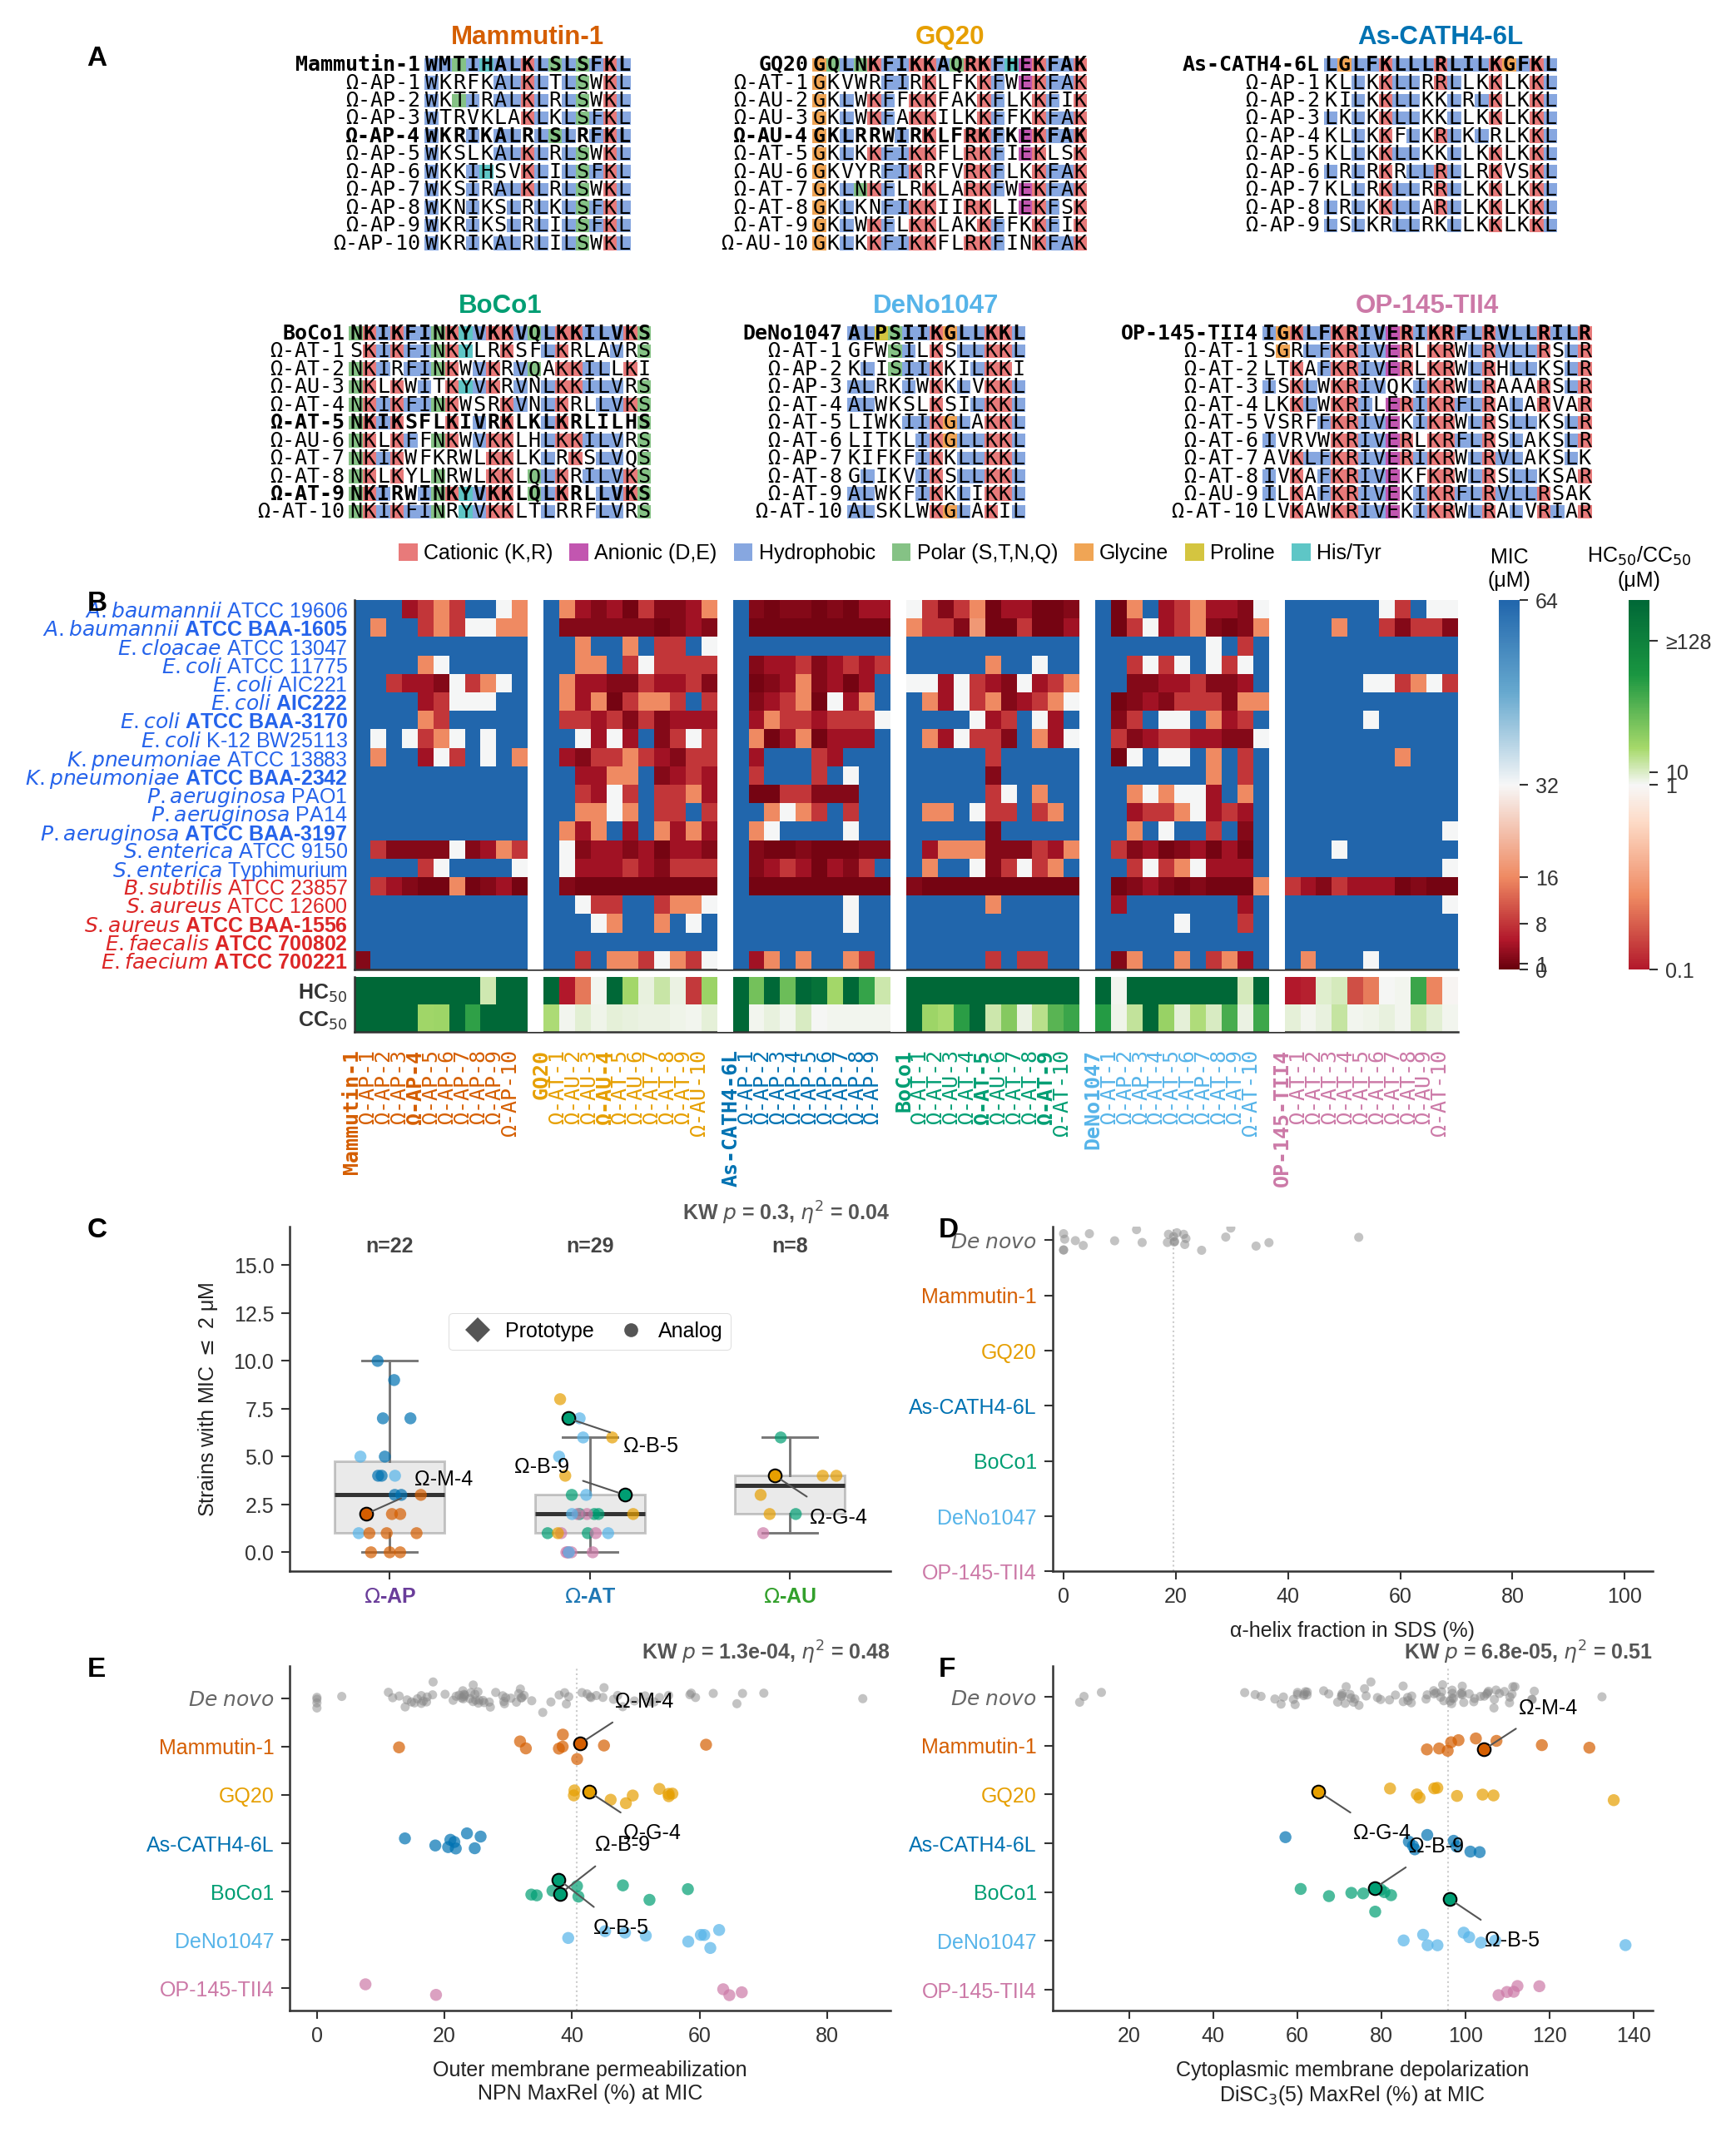

In [11]:
fig = plt.figure(figsize=(6.5, 8.0))

L = dict(fontsize=8, fontweight="bold", va="top", ha="left")

H = 8.0
def to_frac(inches):
    return inches / H

# ── PANEL A ──────────────────────────────────────────────────────────────────
cell_size_in = 0.055
fig_w_in = 6.5

def _family_data_x_range(fam):
    rows = family_rows(fam)
    labels = [fam]
    for r in rows[1:]:
        labels.append(f"Ω-{r['conditioning']}-{r['short_name'].split('-')[-1]}")
    label_space = max(len(l) for l in labels) + 5.0
    max_len = max(len(r["sequence"]) for r in rows)
    return label_space + max_len + 0.3, len(rows)

sub_w = {}
sub_h = {}
row_stride = 1.3
for fam in INACTIVE_ORDER:
    dx, n = _family_data_x_range(fam)
    sub_w[fam] = dx * cell_size_in / fig_w_in
    sub_h[fam] = ((n - 1) * row_stride + 2.2) * cell_size_in / H

gap_fig = 0.008
row_fams = [INACTIVE_ORDER[:3], INACTIVE_ORDER[3:]]
row_widths = [sum(sub_w[f] for f in r) + (len(r) - 1) * gap_fig for r in row_fams]
row_heights = [max(sub_h[f] for f in r) for r in row_fams]

inter_grid_gap = 0.030
top_margin = to_frac(0.10)
y_cursor = 1.0 - top_margin

A_TOP = y_cursor
for row_i, fams in enumerate(row_fams):
    row_left = (1.0 - row_widths[row_i]) / 2
    xpos = row_left
    y_top = y_cursor
    for fam in fams:
        ax = fig.add_axes([xpos, y_top - sub_h[fam], sub_w[fam], sub_h[fam]])
        draw_alignment(ax, fam, fontsize=6, row_stride=row_stride)
        xpos += sub_w[fam] + gap_fig
    y_cursor -= row_heights[row_i]
    if row_i == 0:
        y_cursor -= inter_grid_gap
fig.text(0.005, A_TOP, "A", **L)

# ── AA chemistry legend ──────────────────────────────────────────────────────
y_cursor -= to_frac(0.04)
legend_items = [
    ("Cationic (K,R)", "#E87A7A"), ("Anionic (D,E)", "#C256B0"),
    ("Hydrophobic", "#87A7E0"), ("Polar (S,T,N,Q)", "#85C285"),
    ("Glycine", "#F0A555"), ("Proline", "#D4C540"), ("His/Tyr", "#5EC6C6"),
]
handles = [Patch(facecolor=c, edgecolor="none", label=l) for l, c in legend_items]
fig.legend(handles=handles, loc="upper center",
           bbox_to_anchor=(0.5, y_cursor),
           ncol=len(legend_items), fontsize=6, frameon=False,
           handletextpad=0.3, columnspacing=0.8,
           handlelength=0.9, handleheight=0.9, borderpad=0)
y_cursor -= to_frac(0.09)
y_cursor -= to_frac(0.18)   # A → B: increased gap

# ── PANEL B: heatmap ─────────────────────────────────────────────────────────
B_MIC_TOP = y_cursor
y_cursor -= to_frac(1.48)
B_MIC_BOT = y_cursor
y_cursor -= to_frac(0.03)
B_TOX_TOP = y_cursor
y_cursor -= to_frac(0.22)
B_TOX_BOT = y_cursor

b_left, b_right = 0.17, 0.85
ax_mic = fig.add_axes([b_left, B_MIC_BOT, b_right - b_left, B_MIC_TOP - B_MIC_BOT])
ax_tox = fig.add_axes([b_left, B_TOX_BOT, b_right - b_left, B_TOX_TOP - B_TOX_BOT])
cax_mic = fig.add_axes([b_right + 0.025, B_MIC_BOT, 0.013, B_MIC_TOP - B_MIC_BOT])
cax_tox = fig.add_axes([b_right + 0.105, B_MIC_BOT, 0.013, B_MIC_TOP - B_MIC_BOT])
draw_full_heatmap(ax_mic, ax_tox, cax_mic, cax_tox)
fig.text(0.005, B_MIC_TOP + 0.005, "B", **L)

y_cursor -= to_frac(0.38)   # 90° xtick label space
y_cursor -= to_frac(0.40)   # B → CD: increased gap

# ── Shared left/right edges for C, D, E, F (same width) ──────────────────────
P_LEFT_L  = 0.13   # left edge of left panels  (C, E)
P_RIGHT_L = 0.50   # right edge of left panels
P_LEFT_R  = 0.60   # left edge of right panels (D, F)
P_RIGHT_R = 0.97   # right edge of right panels

PANEL_H = 1.38     # uniform height in inches for all four panels

# ── PANELS C + D ─────────────────────────────────────────────────────────────
CD_TOP = y_cursor
y_cursor -= to_frac(PANEL_H)
CD_BOT = y_cursor

ax_c = fig.add_axes([P_LEFT_L, CD_BOT, P_RIGHT_L - P_LEFT_L, CD_TOP - CD_BOT])
draw_cond_panel(ax_c)
fig.text(0.005, CD_TOP + 0.005, "C", **L)

# Prototype / Analog marker legend at y≈13 in data coords (ylim -1 to 17 → axes fraction ≈0.78)
ax_c.legend(
    handles=[
        Line2D([], [], marker="D", color="w", markerfacecolor="#555",
               markeredgecolor="none", markersize=5, lw=0, label="Prototype"),
        Line2D([], [], marker="o", color="w", markerfacecolor="#555",
               markeredgecolor="none", markersize=4, lw=0, label="Analog"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 0.78),
    ncol=2, fontsize=6,
    frameon=True, framealpha=0.95, edgecolor="#ddd",
    handletextpad=0.3, columnspacing=0.8,
)

ax_d = fig.add_axes([P_LEFT_R, CD_BOT, P_RIGHT_R - P_LEFT_R, CD_TOP - CD_BOT])
draw_helix_panel(ax_d)
fig.text(P_LEFT_R - 0.07, CD_TOP + 0.005, "D", **L)

y_cursor -= to_frac(0.38)   # CD → EF gap

# ── PANELS E + F ─────────────────────────────────────────────────────────────
EF_TOP = y_cursor
y_cursor -= to_frac(PANEL_H)
EF_BOT = y_cursor

ax_e = fig.add_axes([P_LEFT_L, EF_BOT, P_RIGHT_L - P_LEFT_L, EF_TOP - EF_BOT])
fig.text(0.005, EF_TOP + 0.005, "E", **L)

ax_f = fig.add_axes([P_LEFT_R, EF_BOT, P_RIGHT_R - P_LEFT_R, EF_TOP - EF_BOT])
fig.text(P_LEFT_R - 0.07, EF_TOP + 0.005, "F", **L)

draw_membrane_panels(ax_e, ax_f)

plt.show()

## Save


In [12]:
out_png = OUT / "figureS4_analog-wet.png"
out_pdf = OUT / "figureS4_analog-wet.pdf"
out_svg = OUT / "figureS4_analog-wet.svg"
fig.savefig(out_png, dpi=400, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_svg, bbox_inches="tight")
print(f"saved: {out_png}")
print(f"saved: {out_pdf}")
print(f"saved: {out_svg}")


saved: /home/pszymczak/code/omegamp-dashboard/figures/figureS4_analog-wet.png
saved: /home/pszymczak/code/omegamp-dashboard/figures/figureS4_analog-wet.pdf
saved: /home/pszymczak/code/omegamp-dashboard/figures/figureS4_analog-wet.svg
